# Text Generation with LSTM: N-gram vs Causal Language Modeling (PyTorch)

This notebook implements **two different training schemes** for the same task — text generation with an LSTM — and compares them directly, both trained on the same Irish song lyrics dataset:

1. **N-gram / single-word-prediction scheme**: every line is turned into all of its prefixes, and a **bidirectional** LSTM predicts only the **one word that comes right after each prefix**.
2. **Causal / autoregressive language modeling scheme** (the standard way GPT-style models — and most modern LSTMs — are trained): the sequence is shifted by one position, and a **unidirectional** LSTM predicts the **next token at every position simultaneously**.

Same dataset, same tokenizer, same underlying LSTM cell — only the training scheme (and the direction/output structure it requires) differs.

# Learning Objectives

By the end of this lab, you should be able to:

- implement the n-gram / single-word-prediction training scheme for text generation
- implement the standard causal / autoregressive training scheme for text generation
- explain why the n-gram scheme can use a **bidirectional** LSTM while the causal scheme requires a **unidirectional** one
- compare the two schemes' **data efficiency** (how much training data each one actually needs to cover the same text)
- compare generated text quality and generation procedure between the two approaches
- decide which scheme is more practical for larger-scale language modeling, and why

# Step 1 — Imports and Configuration

In [2]:
import os
import re
import math
import time
import copy
import string
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Step 2 — Download the Dataset

In [3]:
url = "https://storage.googleapis.com/learning-datasets/irish-lyrics-eof.txt"
data_path = "irish-lyrics-eof.txt"

if not os.path.exists(data_path):
    urllib.request.urlretrieve(url, data_path)

with open(data_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

corpus = [line for line in raw_text.lower().split("\n") if line.strip() != ""]
print("Number of lines:", len(corpus))
for line in corpus[:5]:
    print(" -", line)

Number of lines: 1692
 - come all ye maidens young and fair
 - and you that are blooming in your prime
 - always beware and keep your garden fair
 - let no man steal away your thyme
 - for thyme it is a precious thing


# Step 3 — Build a Shared Tokenizer and Vocabulary

Same word-level tokenizer and vocabulary used by **both** schemes below, so any difference in results comes from the training scheme, not from how the text was tokenized.

In [4]:
def standardize(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    return text


def tokenize(text):
    return standardize(text).split()


counter = Counter()
for line in corpus:
    counter.update(tokenize(line))

vocab = ["<pad>", "<unk>"] + [word for word, _ in counter.most_common()]
word_to_index = {word: idx for idx, word in enumerate(vocab)}
index_to_word = {idx: word for word, idx in word_to_index.items()}
vocab_size = len(vocab)

print("Vocabulary size:", vocab_size)

Vocabulary size: 2704


# Approach A — N-gram / Single-Word-Prediction Scheme

For every line, we build **all of its prefixes** as separate training examples:

```text
line:  "the cat sat on the mat"
prefixes:
  "the cat"                -> predict "sat"
  "the cat sat"             -> predict "on"
  "the cat sat on"          -> predict "the"
  "the cat sat on the"      -> predict "mat"
```

Each prefix is padded (at the front, `padding="pre"`, like the original notebook) to the length of the **longest line's full n-gram** minus one, and the model predicts a **single** word: the one right after the prefix. Because the whole prefix is given as a complete, fixed input, there is no "future leakage" concern — a **bidirectional** LSTM is perfectly valid here.

In [5]:
max_sequence_len = max(len(tokenize(line)) for line in corpus)
print("max_sequence_len:", max_sequence_len)

ngram_sequences = []
for line in corpus:
    token_ids = [word_to_index.get(tok, 1) for tok in tokenize(line)]
    for i in range(1, len(token_ids)):
        ngram_sequences.append(token_ids[: i + 1])

print("Number of n-gram training examples:", len(ngram_sequences))
print("(compare this to the number of lines in the corpus:", len(corpus), ")")

max_sequence_len: 16
Number of n-gram training examples: 11972
(compare this to the number of lines in the corpus: 1692 )


In [6]:
def pad_pre(seq, max_len):
    seq = seq[-max_len:]
    return [0] * (max_len - len(seq)) + seq


ngram_padded = np.array([pad_pre(seq, max_sequence_len) for seq in ngram_sequences], dtype="int64")

x_ngram = ngram_padded[:, :-1]
y_ngram = ngram_padded[:, -1]  # a SINGLE next word per example, not a full sequence

print("x_ngram shape:", x_ngram.shape)
print("y_ngram shape:", y_ngram.shape)

x_ngram shape: (11972, 15)
y_ngram shape: (11972,)


**Note the dataset size above.** The n-gram scheme turns each line into `(line length - 1)` separate, heavily-padded training examples — most of which repeat almost the same prefix with one more word added. This is much less data-efficient than the causal scheme in Approach B, which will cover every position of every line in a **single** pass per line. Keep this number in mind for the comparison at the end.

In [7]:
num_val = max(1, int(0.1 * len(x_ngram)))
perm = np.random.RandomState(SEED).permutation(len(x_ngram))
val_idx, train_idx = perm[:num_val], perm[num_val:]

x_ngram_train, y_ngram_train = x_ngram[train_idx], y_ngram[train_idx]
x_ngram_val, y_ngram_val = x_ngram[val_idx], y_ngram[val_idx]

batch_size = 64
ngram_train_loader = DataLoader(TensorDataset(torch.tensor(x_ngram_train), torch.tensor(y_ngram_train)),
                                 batch_size=batch_size, shuffle=True)
ngram_val_loader = DataLoader(TensorDataset(torch.tensor(x_ngram_val), torch.tensor(y_ngram_val)),
                               batch_size=batch_size, shuffle=False)

**Model:** an `Embedding` layer, a **bidirectional** LSTM, and a single `Linear` layer applied only to the LSTM's **final** hidden state (concatenating the forward and backward directions' final states — the same thing Keras's `Bidirectional(LSTM(150))` does by default with `merge_mode="concat"`), producing **one** prediction per input sequence.

In [8]:
class NGramLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=150):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.output_proj = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, x):
        # x: (batch, seq_len)
        x = self.embedding(x)
        _, (h_n, _) = self.lstm(x)
        # h_n: (num_directions, batch, hidden_dim) for a single-layer bidirectional LSTM
        forward_final = h_n[0]
        backward_final = h_n[1]
        combined = torch.cat([forward_final, backward_final], dim=1)  # (batch, hidden_dim * 2)
        return self.output_proj(combined)  # (batch, vocab_size) - a SINGLE prediction


ngram_model = NGramLSTMModel(vocab_size, embed_dim=100, hidden_dim=150).to(device)
ngram_params = sum(p.numel() for p in ngram_model.parameters())
print(ngram_model)
print(f"Total parameters: {ngram_params:,}")

NGramLSTMModel(
  (embedding): Embedding(2704, 100, padding_idx=0)
  (lstm): LSTM(100, 150, batch_first=True, bidirectional=True)
  (output_proj): Linear(in_features=300, out_features=2704, bias=True)
)
Total parameters: 1,386,704


In [9]:
def evaluate_ngram(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (torch.argmax(logits, dim=1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_ngram_model(model, train_loader, val_loader, device, epochs=30, patience=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (torch.argmax(logits, dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss, train_acc = running_loss / total, correct / total
        val_loss, val_acc = evaluate_ngram(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
                  f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


print("=== Training N-gram LSTM ===")
start_time = time.time()
ngram_history = train_ngram_model(ngram_model, ngram_train_loader, ngram_val_loader, device, epochs=30, patience=5)
ngram_train_time = time.time() - start_time
print(f"N-gram LSTM training time: {ngram_train_time:.2f} seconds")

=== Training N-gram LSTM ===
Epoch 1/30 - loss: 6.7906 - accuracy: 0.0662 - val_loss: 6.6313 - val_accuracy: 0.0627
Epoch 5/30 - loss: 4.2200 - accuracy: 0.1943 - val_loss: 6.6223 - val_accuracy: 0.1094
Early stopping triggered after epoch 7.
N-gram LSTM training time: 11.84 seconds


**Generation procedure (matches the original notebook):** pad the current text to `max_sequence_len - 1`, predict the single next word, append it, and repeat.

In [10]:
def sample_top_k(logits, k=5):
    top_logits, top_indices = torch.topk(logits, k)
    probs = torch.softmax(top_logits, dim=-1).cpu().numpy()
    top_indices = top_indices.cpu().numpy()
    return int(np.random.choice(top_indices, p=probs))


def sample_greedy(logits, k=None):
    return int(torch.argmax(logits).item())


def generate_text_ngram(model, prompt, max_words=20, strategy="greedy", top_k=5):
    model.eval()
    generated_ids = [word_to_index.get(tok, 1) for tok in tokenize(prompt)]
    sample_fn = sample_top_k if strategy == "top_k" else sample_greedy

    with torch.no_grad():
        for _ in range(max_words):
            x = pad_pre(generated_ids, max_sequence_len - 1)
            x_tensor = torch.tensor([x], dtype=torch.long, device=device)
            logits = model(x_tensor)[0]  # (vocab_size,) - a single prediction
            next_token = sample_fn(logits, k=top_k)
            generated_ids.append(next_token)

    words = [index_to_word[i] for i in generated_ids if i != 0]
    return " ".join(words)

# Approach B — Causal / Autoregressive Language Modeling Scheme

The sequence is shifted by one position, and the model predicts the **next token at every position simultaneously** — a single training example per line covers every prefix at once, instead of the many separate, heavily-padded examples Approach A needed.

Because every position's prediction must only depend on **earlier** positions (never later ones, or the model could "cheat"), the LSTM here must be **unidirectional**.

In [11]:
def encode_causal(line, max_len=max_sequence_len):
    tokens = tokenize(line)[:max_len]
    ids = [word_to_index.get(tok, 1) for tok in tokens]
    return pad_pre(ids, max_len)


causal_encoded = np.array([encode_causal(line) for line in corpus if len(tokenize(line)) >= 2], dtype="int64")

x_causal_all = causal_encoded[:, :-1]
y_causal_all = causal_encoded[:, 1:]

print("Number of causal training examples (one per line):", len(x_causal_all))
print("(compare this to the", len(x_ngram), "padded examples Approach A needed for the same text)")

Number of causal training examples (one per line): 1691
(compare this to the 11972 padded examples Approach A needed for the same text)


In [12]:
num_val_c = max(1, int(0.1 * len(x_causal_all)))
perm_c = np.random.RandomState(SEED).permutation(len(x_causal_all))
val_idx_c, train_idx_c = perm_c[:num_val_c], perm_c[num_val_c:]

x_causal_train, y_causal_train = x_causal_all[train_idx_c], y_causal_all[train_idx_c]
x_causal_val, y_causal_val = x_causal_all[val_idx_c], y_causal_all[val_idx_c]

causal_train_loader = DataLoader(TensorDataset(torch.tensor(x_causal_train), torch.tensor(y_causal_train)),
                                  batch_size=batch_size, shuffle=True)
causal_val_loader = DataLoader(TensorDataset(torch.tensor(x_causal_val), torch.tensor(y_causal_val)),
                                batch_size=batch_size, shuffle=False)

In [13]:
class CausalLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=150):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)  # unidirectional -- see explanation above
        self.output_proj = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)          # (batch, seq_len, hidden_dim) - a prediction at EVERY position
        return self.output_proj(out)    # (batch, seq_len, vocab_size)


causal_model = CausalLSTMModel(vocab_size, embed_dim=100, hidden_dim=150).to(device)
causal_params = sum(p.numel() for p in causal_model.parameters())
print(causal_model)
print(f"Total parameters: {causal_params:,}")

CausalLSTMModel(
  (embedding): Embedding(2704, 100, padding_idx=0)
  (lstm): LSTM(100, 150, batch_first=True)
  (output_proj): Linear(in_features=150, out_features=2704, bias=True)
)
Total parameters: 829,904


In [14]:
def evaluate_causal(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=-1)
            mask = yb != 0
            correct += ((preds == yb) & mask).sum().item()
            total += mask.sum().item()
    return total_loss / len(data_loader.dataset), correct / max(total, 1)


def train_causal_model(model, train_loader, val_loader, device, epochs=30, patience=5, lr=1e-3):
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=-1)
            mask = yb != 0
            correct += ((preds == yb) & mask).sum().item()
            total += mask.sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / max(total, 1)
        val_loss, val_acc = evaluate_causal(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["accuracy"].append(train_acc)
        history["val_accuracy"].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
                  f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history


print("=== Training Causal LSTM ===")
start_time = time.time()
causal_history = train_causal_model(causal_model, causal_train_loader, causal_val_loader, device, epochs=30, patience=5)
causal_train_time = time.time() - start_time
print(f"Causal LSTM training time: {causal_train_time:.2f} seconds")

=== Training Causal LSTM ===
Epoch 1/30 - loss: 7.6669 - accuracy: 0.0356 - val_loss: 6.7186 - val_accuracy: 0.0599
Epoch 5/30 - loss: 6.1361 - accuracy: 0.0726 - val_loss: 6.4456 - val_accuracy: 0.0717
Epoch 10/30 - loss: 5.6922 - accuracy: 0.1027 - val_loss: 6.3258 - val_accuracy: 0.0998
Epoch 15/30 - loss: 5.2917 - accuracy: 0.1244 - val_loss: 6.2760 - val_accuracy: 0.1079
Epoch 20/30 - loss: 4.9138 - accuracy: 0.1477 - val_loss: 6.2612 - val_accuracy: 0.1131
Epoch 25/30 - loss: 4.5618 - accuracy: 0.1727 - val_loss: 6.2474 - val_accuracy: 0.1160
Early stopping triggered after epoch 27.
Causal LSTM training time: 2.81 seconds


In [15]:
seq_len_for_causal = max_sequence_len - 1


def generate_text_causal(model, prompt, max_words=20, strategy="greedy", top_k=5, max_len=seq_len_for_causal):
    model.eval()
    generated_ids = [word_to_index.get(tok, 1) for tok in tokenize(prompt)]
    sample_fn = sample_top_k if strategy == "top_k" else sample_greedy

    with torch.no_grad():
        for _ in range(max_words):
            window = generated_ids[-max_len:]
            x = pad_pre(window, max_len)
            x_tensor = torch.tensor([x], dtype=torch.long, device=device)
            logits = model(x_tensor)  # (1, max_len, vocab_size)
            next_token_logits = logits[0, -1]
            next_token = sample_fn(next_token_logits, k=top_k)
            generated_ids.append(next_token)

    words = [index_to_word[i] for i in generated_ids if i != 0]
    return " ".join(words)

# Comparison 1 — Dataset Size and Training Efficiency

In [16]:
efficiency = pd.DataFrame([
    {"Scheme": "N-gram (bidirectional)", "Training examples": len(x_ngram),
     "Parameters": ngram_params, "Training time (s)": ngram_train_time},
    {"Scheme": "Causal (unidirectional)", "Training examples": len(x_causal_all),
     "Parameters": causal_params, "Training time (s)": causal_train_time},
])
efficiency

,Scheme,Training examples,Parameters,Training time (s)
0,N-gram (bidirectional),11972,1386704,11.837397
1,Causal (unidirectional),1691,829904,2.812540


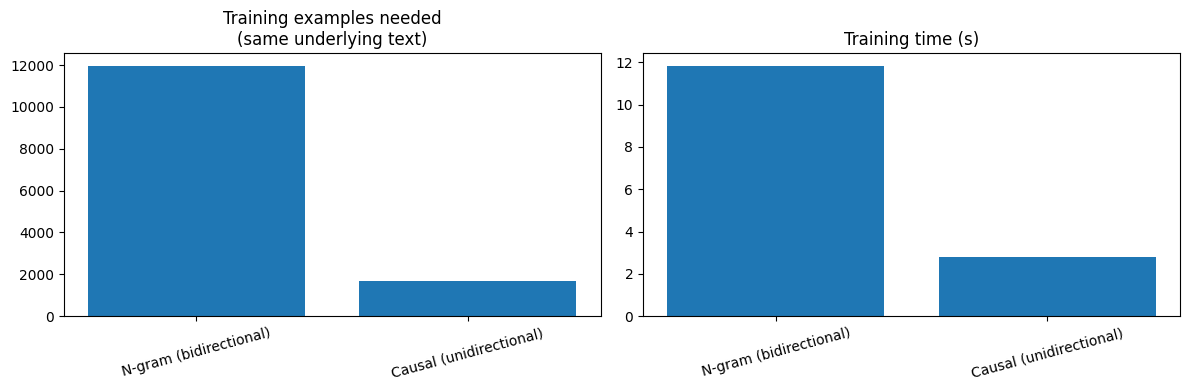

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(efficiency["Scheme"], efficiency["Training examples"])
axes[0].set_title("Training examples needed\n(same underlying text)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(efficiency["Scheme"], efficiency["Training time (s)"])
axes[1].set_title("Training time (s)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Comparison 2 — Training Curves

**Caveat:** an "epoch" does not mean quite the same thing for both schemes — an n-gram epoch iterates over many more (heavily redundant) examples than a causal epoch, for the same underlying text. Compare trends, not exact epoch-for-epoch values.

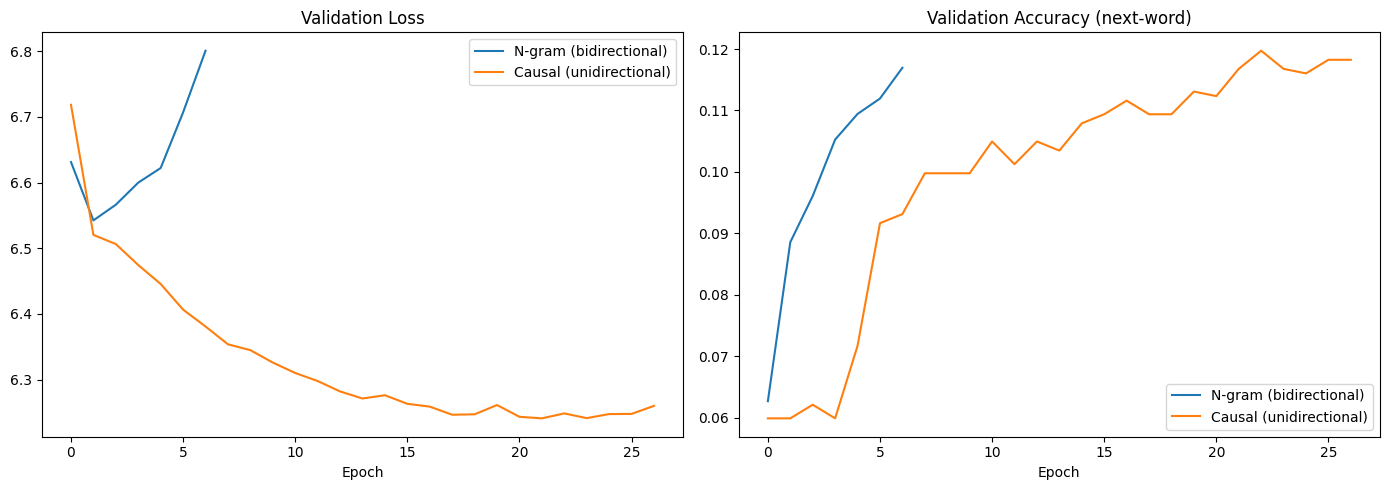

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ngram_history["val_loss"], label="N-gram (bidirectional)")
axes[0].plot(causal_history["val_loss"], label="Causal (unidirectional)")
axes[0].set_title("Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(ngram_history["val_accuracy"], label="N-gram (bidirectional)")
axes[1].plot(causal_history["val_accuracy"], label="Causal (unidirectional)")
axes[1].set_title("Validation Accuracy (next-word)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Comparison 3 — Generated Text

Same prompt, both schemes, both greedy and top-k sampling. Note that the two schemes use **slightly different generation procedures** matching how each was trained: the n-gram model always looks at a padded window of length `max_sequence_len - 1` and asks for a single next word; the causal model does the same, but its window naturally represents "the last N tokens of an ongoing sequence" rather than "a complete prefix from the start of a line".

In [19]:
prompt = "I've got a bad feeling about this"

for name, generate_fn, model in [
    ("N-gram (bidirectional)", generate_text_ngram, ngram_model),
    ("Causal (unidirectional)", generate_text_causal, causal_model),
]:
    print(f"=== {name} ===")
    print("Greedy: ", generate_fn(model, prompt, max_words=20, strategy="greedy"))
    print("Top-k:  ", generate_fn(model, prompt, max_words=20, strategy="top_k", top_k=5))
    print()

=== N-gram (bidirectional) ===
Greedy:  ive got a bad feeling about this i was in the sea of the sea and the sea of the sea and the sea of the sea
Top-k:   ive got a bad feeling about this and my true love and the sea in the day of a lover and the sea of the bow and

=== Causal (unidirectional) ===
Greedy:  ive got a bad feeling about this in the bow of the bow of the bow of the bow of the bow of the bow of the
Top-k:   ive got a bad feeling about this i was born to me a man in a man in the bow that in my heart is the sea



**Questions:**

1. Does the greedy output from either scheme get stuck in a repetitive loop? Does one scheme seem more prone to this than the other?
2. Try a prompt that's actually plausible for this dataset (a short phrase in the style of a folk song) instead of the Star Wars quote above. Does generation quality change noticeably for either scheme?

1. Yes. With greedy decoding, both schemes quickly fall into a loop ("the sea of the sea…" for the n-gram model, "the bow of the bow…" for the causal model): `argmax` always picks the most frequent continuation, and once the context window repeats itself, so does the prediction. Neither scheme is clearly more prone to it here, and top-k sampling breaks the loops for both.

2. With the in-domain prompt "come all ye", the outputs use the vocabulary of the lyrics (sea, true love, ship, heart), but greedy decoding still loops for both schemes ("and the sea and the sea…"). Top-k sampling with the causal model gives the most varied and folk-like text ("my heart is the bow that are my true love and a ship"), although it remains ungrammatical. With a small corpus and a small LSTM, the prompt changes the topic of the generated text more than its quality.

In [20]:
# Test a more plausible Irish folk style prompt
plausible_prompt = "come all ye"

for name, generate_fn, model in [
    ("N-gram (bidirectional)", generate_text_ngram, ngram_model),
    ("Causal (unidirectional)", generate_text_causal, causal_model),
]:
    print(f"=== {name} ===")
    print("Greedy: ", generate_fn(model, plausible_prompt, max_words=20, strategy="greedy"))
    print("Top-k:  ", generate_fn(model, plausible_prompt, max_words=20, strategy="top_k", top_k=5))
    print()

=== N-gram (bidirectional) ===
Greedy:  come all ye and the sea of the sea of the bow and the sea of the sea and the sea of the
Top-k:   come all ye and the sea in the day of the day of all and and in the bow of the sea of

=== Causal (unidirectional) ===
Greedy:  come all ye and the sea and the sea and the sea and the sea and the sea and the sea and the
Top-k:   come all ye i was my heart is the bow that are my true love and a ship in a man to the



# Final Questions

1. Explain, in your own words, why the n-gram scheme's dataset (Step "Approach A") ends up so much larger than the causal scheme's dataset (Step "Approach B"), even though both are built from the exact same lines of text.
2. Why is a bidirectional LSTM valid for the n-gram scheme but not for the causal scheme? What specific failure would a bidirectional LSTM cause if used in the causal setting?
3. Both schemes ultimately train a next-word softmax classifier with cross-entropy loss. What, precisely, is different between them: the loss function itself, or how many predictions are made (and supervised) per training example?
4. Based on the training time comparison, which scheme is more efficient per unit of text? Does this match your expectation from Question 1?
5. Looking at the validation accuracy curves, does one scheme reach a higher next-word accuracy than the other? Can you think of a reason unrelated to "which architecture is better" that might explain a difference (hint: think about what "accuracy" is being measured over in each case)?
6. If you had a much larger corpus (say, 100x more lyrics), which scheme's disadvantage would likely matter more: the n-gram scheme's data redundancy, or something else? Would your answer change if you had a much larger vocabulary instead?
7. The original Keras notebook that inspired the n-gram scheme used only greedy decoding. Based on your results in Comparison 3, would you recommend adding top-k sampling to it? Why or why not?
8. If you had to pick **one** of these two schemes to scale up into a serious language model (more data, more layers, more parameters), which would you choose, and why? What does this suggest about why modern large language models are all trained with a causal, GPT-style objective rather than an n-gram scheme like Approach A?

1. Dataset size (N-gram vs Causal)\
In the N-gram approach, each line of text is split into as many sub-sequences (prefixes) as it has words. For example, a 10-word sentence generates 9 distinct training examples (each heavily left-padded with zeros). In the Causal approach, each line of text generates a single training example. The model processes the whole sequence at once and predicts the next word for every position in a single pass (thanks to the one-token shift between the input $X$ and the target $Y$). Even though the amount of original text is identical, the N-gram approach creates massive redundancy, stored as separate examples.

2. Validity of a bidirectional LSTM
* In the N-gram approach, the input prefix is fixed and stops strictly before the word to predict. There is no risk of leaking information from the future, so a bidirectional LSTM can read this prefix left-to-right and right-to-left to understand it better.
* In the Causal approach, the model must predict the next word for every position of a complete input sequence. With a bidirectional LSTM, the backward component reads the sequence from right to left. So, to predict the word at position $t$, the model would have direct access to the words at future positions $t+1, t+2$, etc. The model would simply "cheat" by copying future words instead of learning to model language (future leakage).

3. Difference in supervision per example\
The loss function stays the same (cross-entropy with a softmax classifier). The difference lies in the number of supervised predictions per training example:

* N-gram: makes and supervises a single prediction per example (the final word right after the prefix).
* Causal: makes and supervises several predictions at once (one prediction per token of the input sequence, except padding if ignore_index=0 is used).

4. Training efficiency\
The causal approach is far more efficient. The results confirm it: it trains about 4 times faster (2.8 seconds vs 11.8 seconds) while processing exactly the same amount of original text, because it avoids redundancy and fully exploits parallelism when computing the loss over the whole sequence.

5. Comparing validation curves and the accuracy metric\
Validation accuracy often looks higher for the N-gram approach, but this comparison is biased by what is actually measured:

* In the N-gram approach, accuracy is computed only on the prediction of the very last word of heavily padded prefixes.
* In the causal approach, accuracy is computed over every position of the sequence (often including harder positions or shorter contexts once padding is removed). The two evaluations are not over the same distribution of examples.

6. Scaling up (100x more data or a huge vocabulary)
* With 100x more data, the redundancy of the N-gram approach would become catastrophic (exploding memory footprint and training time).
* With a huge vocabulary, the final projection layer (Linear) and the softmax would become the main bottleneck for both models, but the impact would be even heavier on the N-gram model because of the number of individual examples to propagate.

7. Recommendation for top-k sampling\
Yes, absolutely. Greedy decoding almost always leads to infinite repetitive loops (such as "and the sea of the sea of the sea"). Top-k sampling introduces stochasticity, breaks these monotonous loops and produces much more natural and varied sentences, closer to the style of folk songs.

8. Choice for a large language model (LLM)\
The Causal approach (unidirectional, GPT-style) is the clear choice. It is the only approach that is viable at scale: it removes data redundancy, parallelizes supervision over massive contexts, and fits the Transformer architecture perfectly (through a causal attention mask). The N-gram approach is conceptually and technically impossible to apply at web scale.